In [1]:
run = "j"

In [2]:
import sys
sys.path.append("../../src/ml")

[LoadML] [OK] Initialised
[Load] [OK] Initialised with out_path=../../output/ml/j/data/CRY_onspill-LH_aw
[Load] [OK] Successfully loaded results from ../../output/ml/j/data/CRY_onspill-LH_aw/results.pkl
[Load] [OK] Initialised with out_path=../../output/ml/j/data/CE_mix2BB_onspill-LH_aw
[Load] [OK] Successfully loaded results from ../../output/ml/j/data/CE_mix2BB_onspill-LH_aw/results.pkl
[LoadML] [OK] Got full results
[Assemble] [OK] Initialised
[Load] [OK] Initialised with out_path=test_out
[pyprint] [INFO] Initialised Print with verbose = False and precision = 1
[Plot] [INFO] Initialised
[Plot] [OK] 	Wrote ../../../output/images/ml/j/process/h1o_3x3_cuts_CRY.png


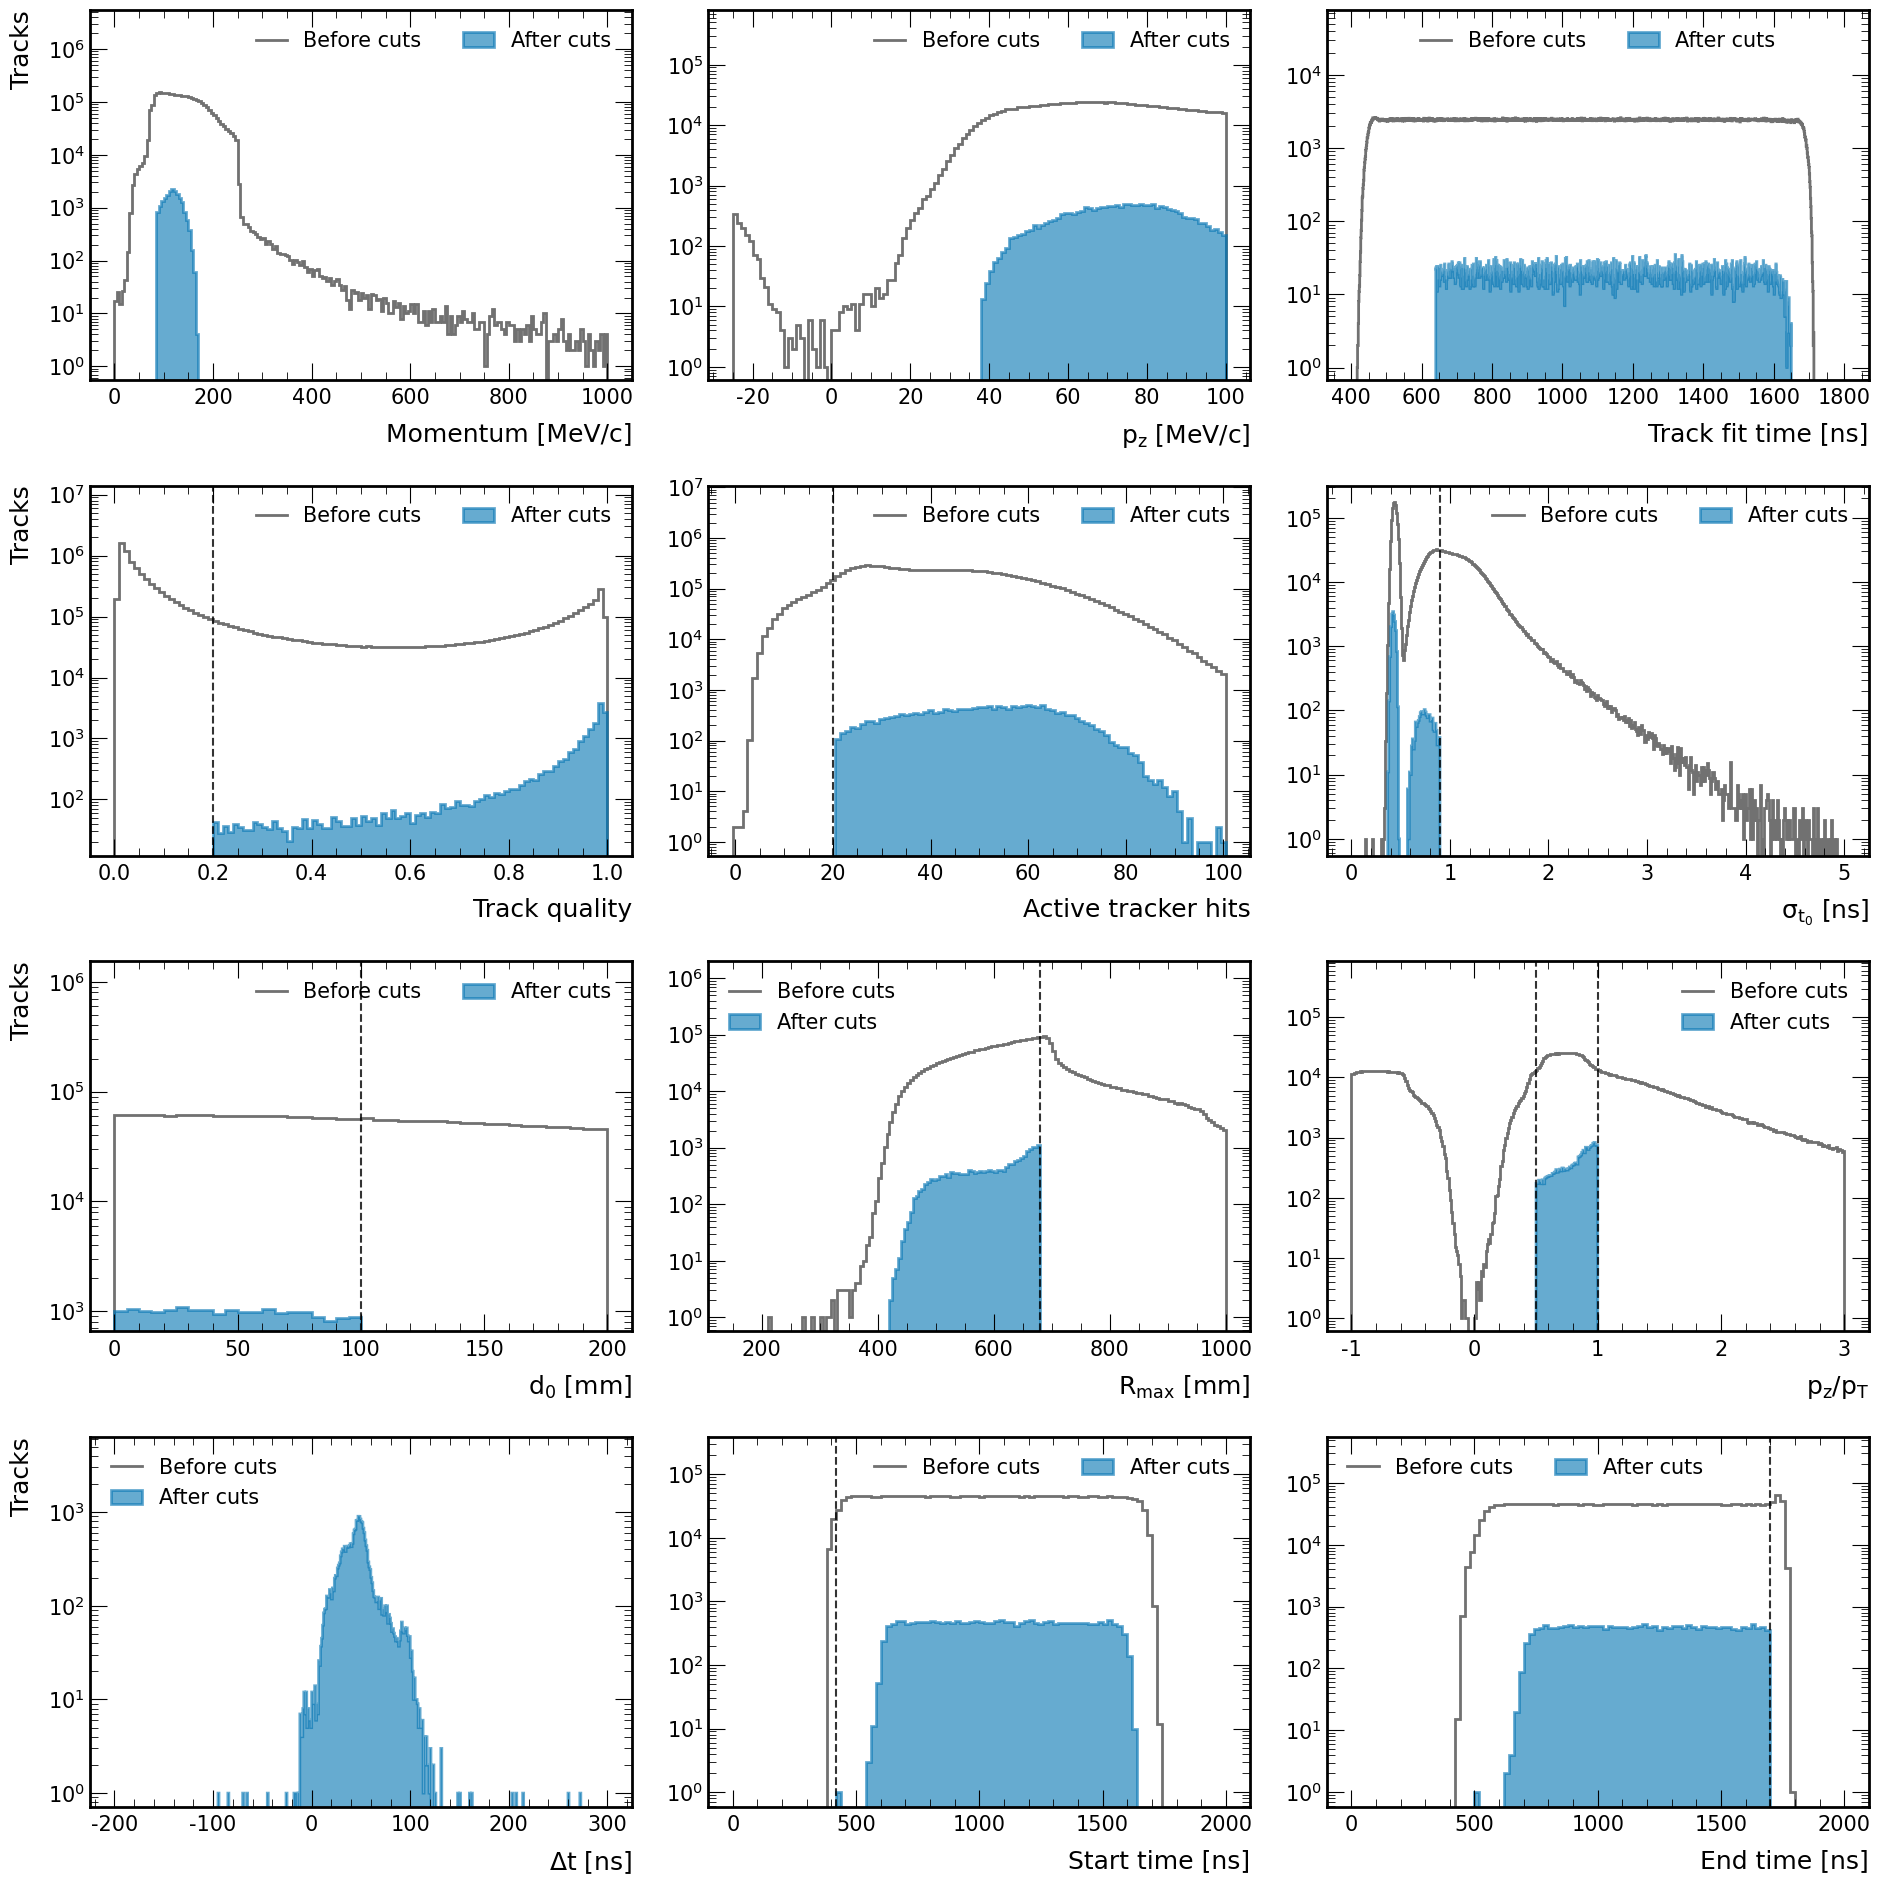

[Plot] [OK] 	Wrote ../../../output/images/ml/j/process/h1o_3x3_cuts_CE_mix.png


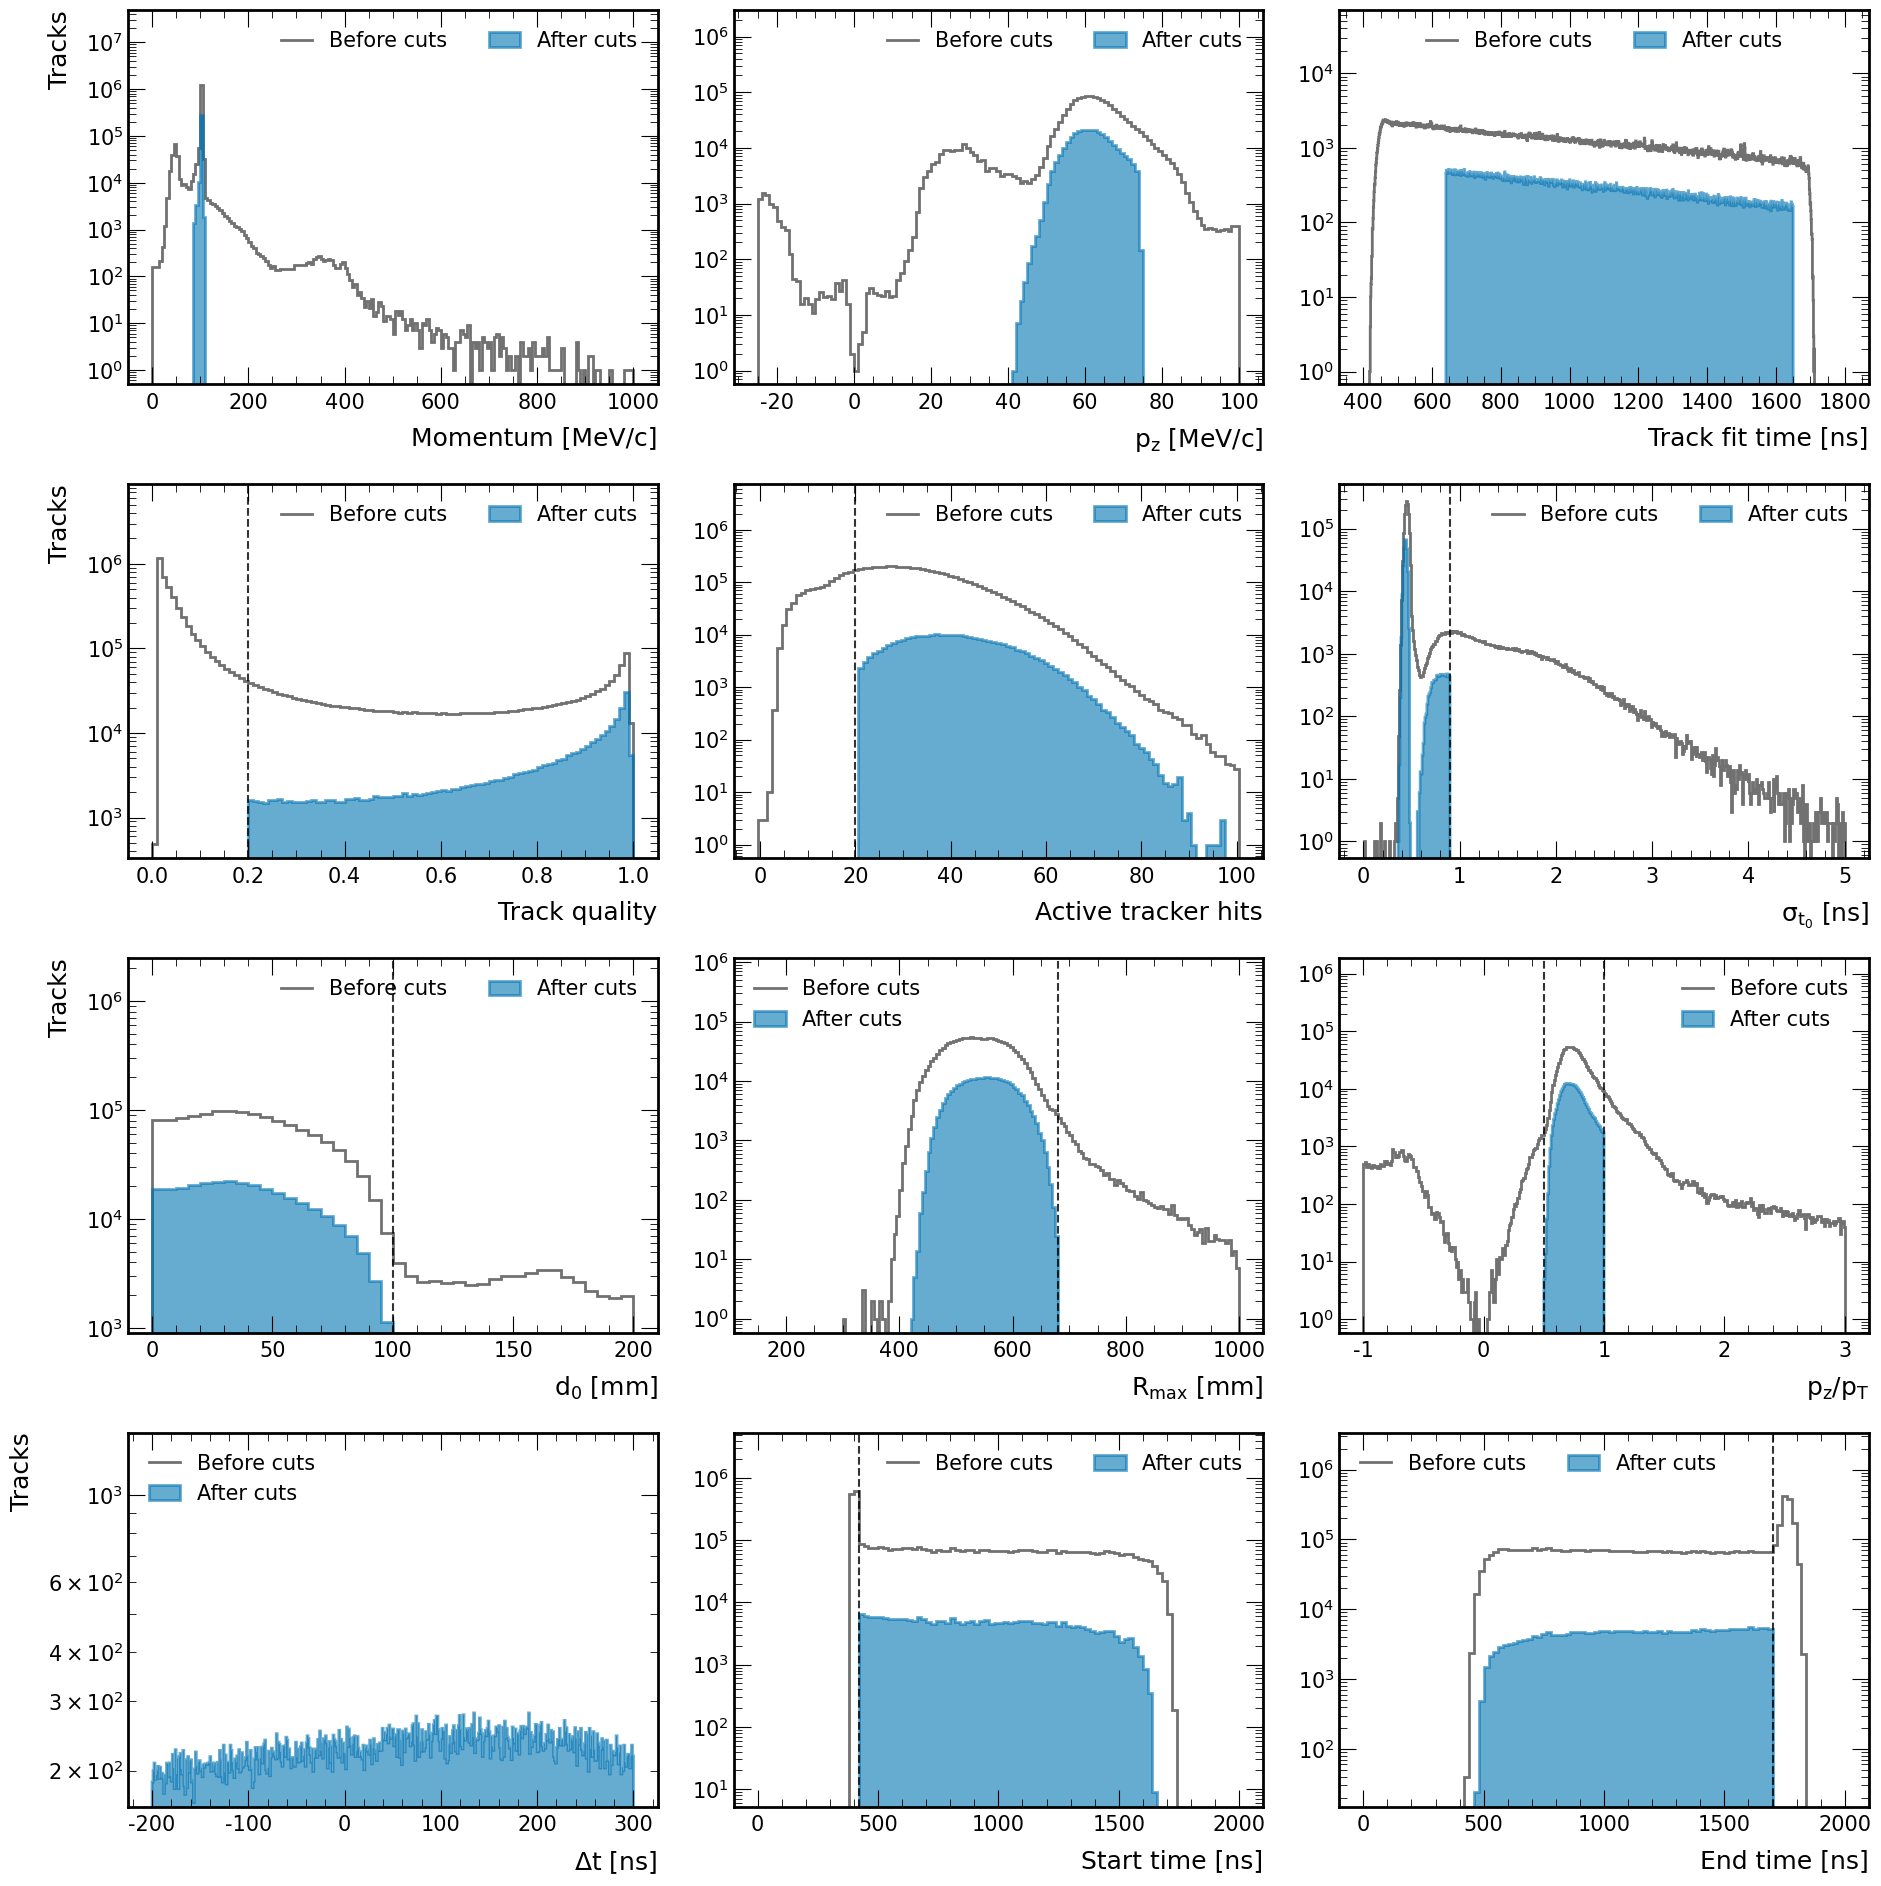

cry:


,Cut,Group,Events Passing,Absolute [%],Relative [%],Description
0,No cuts,NaN,2610933,100.000,100.000,No selection applied
1,thru_trk,Preselect,2528178,96.830,96.830,Tracks intersect full tracker
2,is_reco_electron,Preselect,2447193,93.729,96.797,Select electron track hypothesis
3,one_reco_electron,Preselect,2020330,77.380,82.557,One reco electron / event
4,is_downstream,Preselect,1111321,42.564,55.007,Downstream tracks (p_z > 0 through tracker)
5,is_truth_electron,Preselect,320059,12.258,28.800,Track parents are electrons (truth PID)
6,good_trkqual,Tracker,253908,9.725,79.332,Track quality > 0.2
7,within_t0,Tracker,203298,7.786,80.068,t0 at tracker mid (640 < t_0 < 1650 ns)
8,within_t0err,Tracker,188693,7.227,92.816,Track fit t0 uncertainty (t0err < 0.9 ns)
9,has_hits,Tracker,186108,7.128,98.630,>20 active tracker hits


ce_mix:


,Cut,Group,Events Passing,Absolute [%],Relative [%],Description
0,No cuts,NaN,1339362,100.000,100.000,No selection applied
1,thru_trk,Preselect,1336977,99.822,99.822,Tracks intersect full tracker
2,is_reco_electron,Preselect,1327509,99.115,99.292,Select electron track hypothesis
3,one_reco_electron,Preselect,1097120,81.914,82.645,One reco electron / event
4,is_downstream,Preselect,1096121,81.839,99.909,Downstream tracks (p_z > 0 through tracker)
5,is_truth_electron,Preselect,1096052,81.834,99.994,Track parents are electrons (truth PID)
6,good_trkqual,Tracker,883129,65.937,80.574,Track quality > 0.2
7,within_t0,Tracker,655442,48.937,74.218,t0 at tracker mid (640 < t_0 < 1650 ns)
8,within_t0err,Tracker,636325,47.510,97.083,Track fit t0 uncertainty (t0err < 0.9 ns)
9,has_hits,Tracker,621990,46.439,97.747,>20 active tracker hits


         Metric    CRY  CE Mix
0         Total  19574  297609
1      Unvetoed     10  264758
2  Fraction [%]  99.95   11.04
[Assemble] [DEBUG] Got sorted and labelled DataFrames
[Assemble] [DEBUG] Got combined dataset
[Assemble] [DEBUG] Columns: Index(['event', 'subrun', 'crv_x', 'crv_y', 'crv_z', 'PEs', 'dT', 'nHits',
       'nLayers', 'angle', 'timeStart', 'timeEnd', 'sector', 'PEs_per_hit',
       't0', 'd0', 'tanDip', 'maxr', 'mom_mag', 'label'],
      dtype='str')
[Assemble] [DEBUG] Split data (event-level grouping)
[Assemble] [OK] Got ML data


In [3]:
from assemble import AssembleDataset
assembler = AssembleDataset(run=run, cutset_name="MLPreprocess", verbosity=2)
assembler.draw_hists()
cut_flows = assembler.get_cut_flows()
for name, cut_flow in cut_flows.items():
    print(f"{name}:")
    display(cut_flow)
print(assembler.check_dT_window_results())
data = assembler.assemble_dataset()

In [ ]:
df = data["X_train"]
display(df)

,crv_x,crv_y,crv_z,PEs,dT,nHits,nLayers,angle,sector
0,-1.667161e+03,2712.865723,-4634.554688,170.964264,312.393172,10.0,3.0,-7.330089,3.0
4,-4.547474e-13,2710.952393,-7313.016113,367.999237,722.325689,8.0,3.0,0.326144,3.0
5,4.096708e+03,2880.630371,-9957.799805,602.762268,489.175887,29.0,4.0,0.449854,4.0
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
444336,0.000000e+00,2697.614502,-3182.984619,79.004051,446.703896,7.0,3.0,2.162331,3.0
444337,0.000000e+00,2713.520996,-6189.891113,90.788139,418.593509,6.0,3.0,0.960317,3.0
444339,-1.590384e+03,2705.326660,-5634.797363,469.272675,-69.938230,15.0,3.0,0.329934,3.0
444340,4.343701e+03,2873.293457,-9957.799805,286.017487,-26.453057,17.0,4.0,0.233778,4.0


In [4]:
# Baseline XGBoost
from train import Train
trainer = Train(data)
training_results = trainer.train(
    tag="xgb_optimal",
    save_output=True,
    n_estimators=500,
    max_depth=7,
    learning_rate=0.1
)

[Train] [OK] Initialised
[Train] [INFO] Training model: XGBClassifier
  Tag: xgb_optimal
  Random state: 42
  Scale features: True

[Train] [INFO]   Hyperparams: {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.1}

[Train] [OK] Training complete!
[Train] [OK] Results saved to ../../output/ml/j/results/xgb_optimal/results.pkl


[AnaModel] [OK] Initialised analyser for model: xgb_optimal

  VALIDATION SUMMARY: xgb_optimal



[AnaModel] [INFO] Confusion Matrix:
  TP: 4635, FN: 28
  FP: 18, TN: 84495
[AnaModel] [INFO] ROC AUC:
  Train: 0.9999
  Test:  0.9998
[AnaModel] [INFO] Classification Report:
                precision    recall  f1-score   support

Background (0)       1.00      1.00      1.00     84513
    Signal (1)       1.00      0.99      1.00      4663

      accuracy                           1.00     89176
     macro avg       1.00      1.00      1.00     89176
  weighted avg       1.00      1.00      1.00     89176



Feature importance:
  PEs            : 0.4957
  crv_x          : 0.3092
  nLayers        : 0.1476
  dT             : 0.0250
  crv_y          : 0.0120
  crv_z          : 0.0036
  nHits          : 0.0031
  angle          : 0.0029
  sector         : 0.0009
[AnaModel] [OK] Saved to ../../output/images/ml/j/xgb_optimal/bar_feature_importance.png


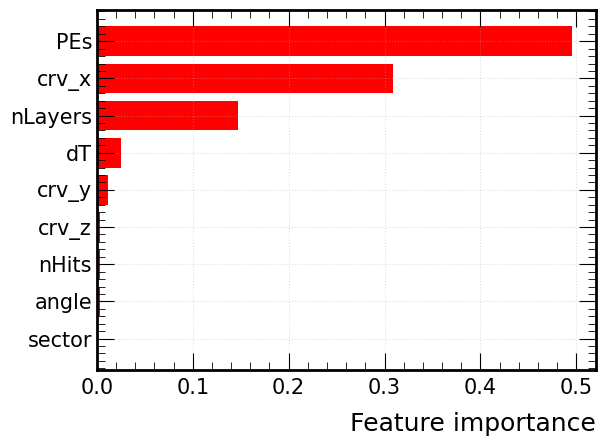

[AnaModel] [OK] Saved to ../../output/images/ml/j/xgb_optimal/roc_curve.png


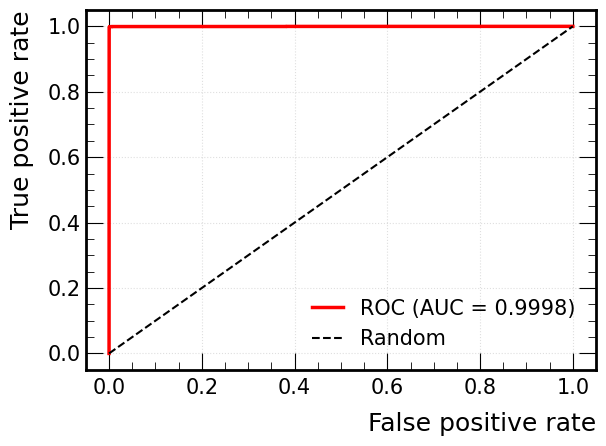

[AnaModel] [INFO] Event-level threshold (target 99.90% veto efficiency):
  Threshold:         0.3317
  Veto efficiency:   99.924%
  Signal efficiency: 99.968%
  Deadtime:          0.032%
[AnaModel] [OK] Saved to ../../output/images/ml/j/xgb_optimal/threshold_overlay.png
[AnaModel] [OK] Saved to ../../output/images/ml/j/xgb_optimal/h1_score_distribution.png


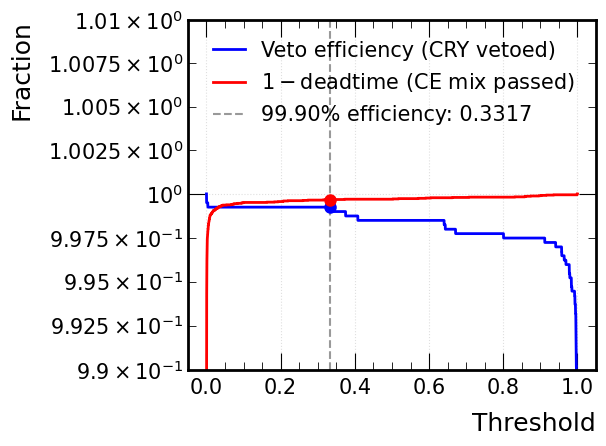

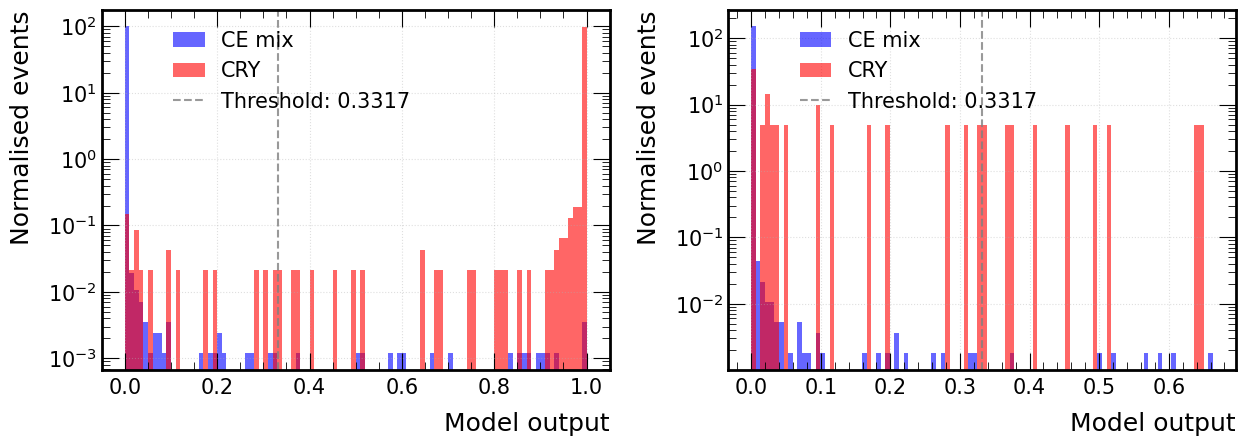

[AnaModel] [INFO] Selected events (score >= 0.3317):
  CRY:    4641
  CE mix: 19
[AnaModel] [OK] Saved to ../../output/images/ml/j/xgb_optimal/h1_high_score_physics.png


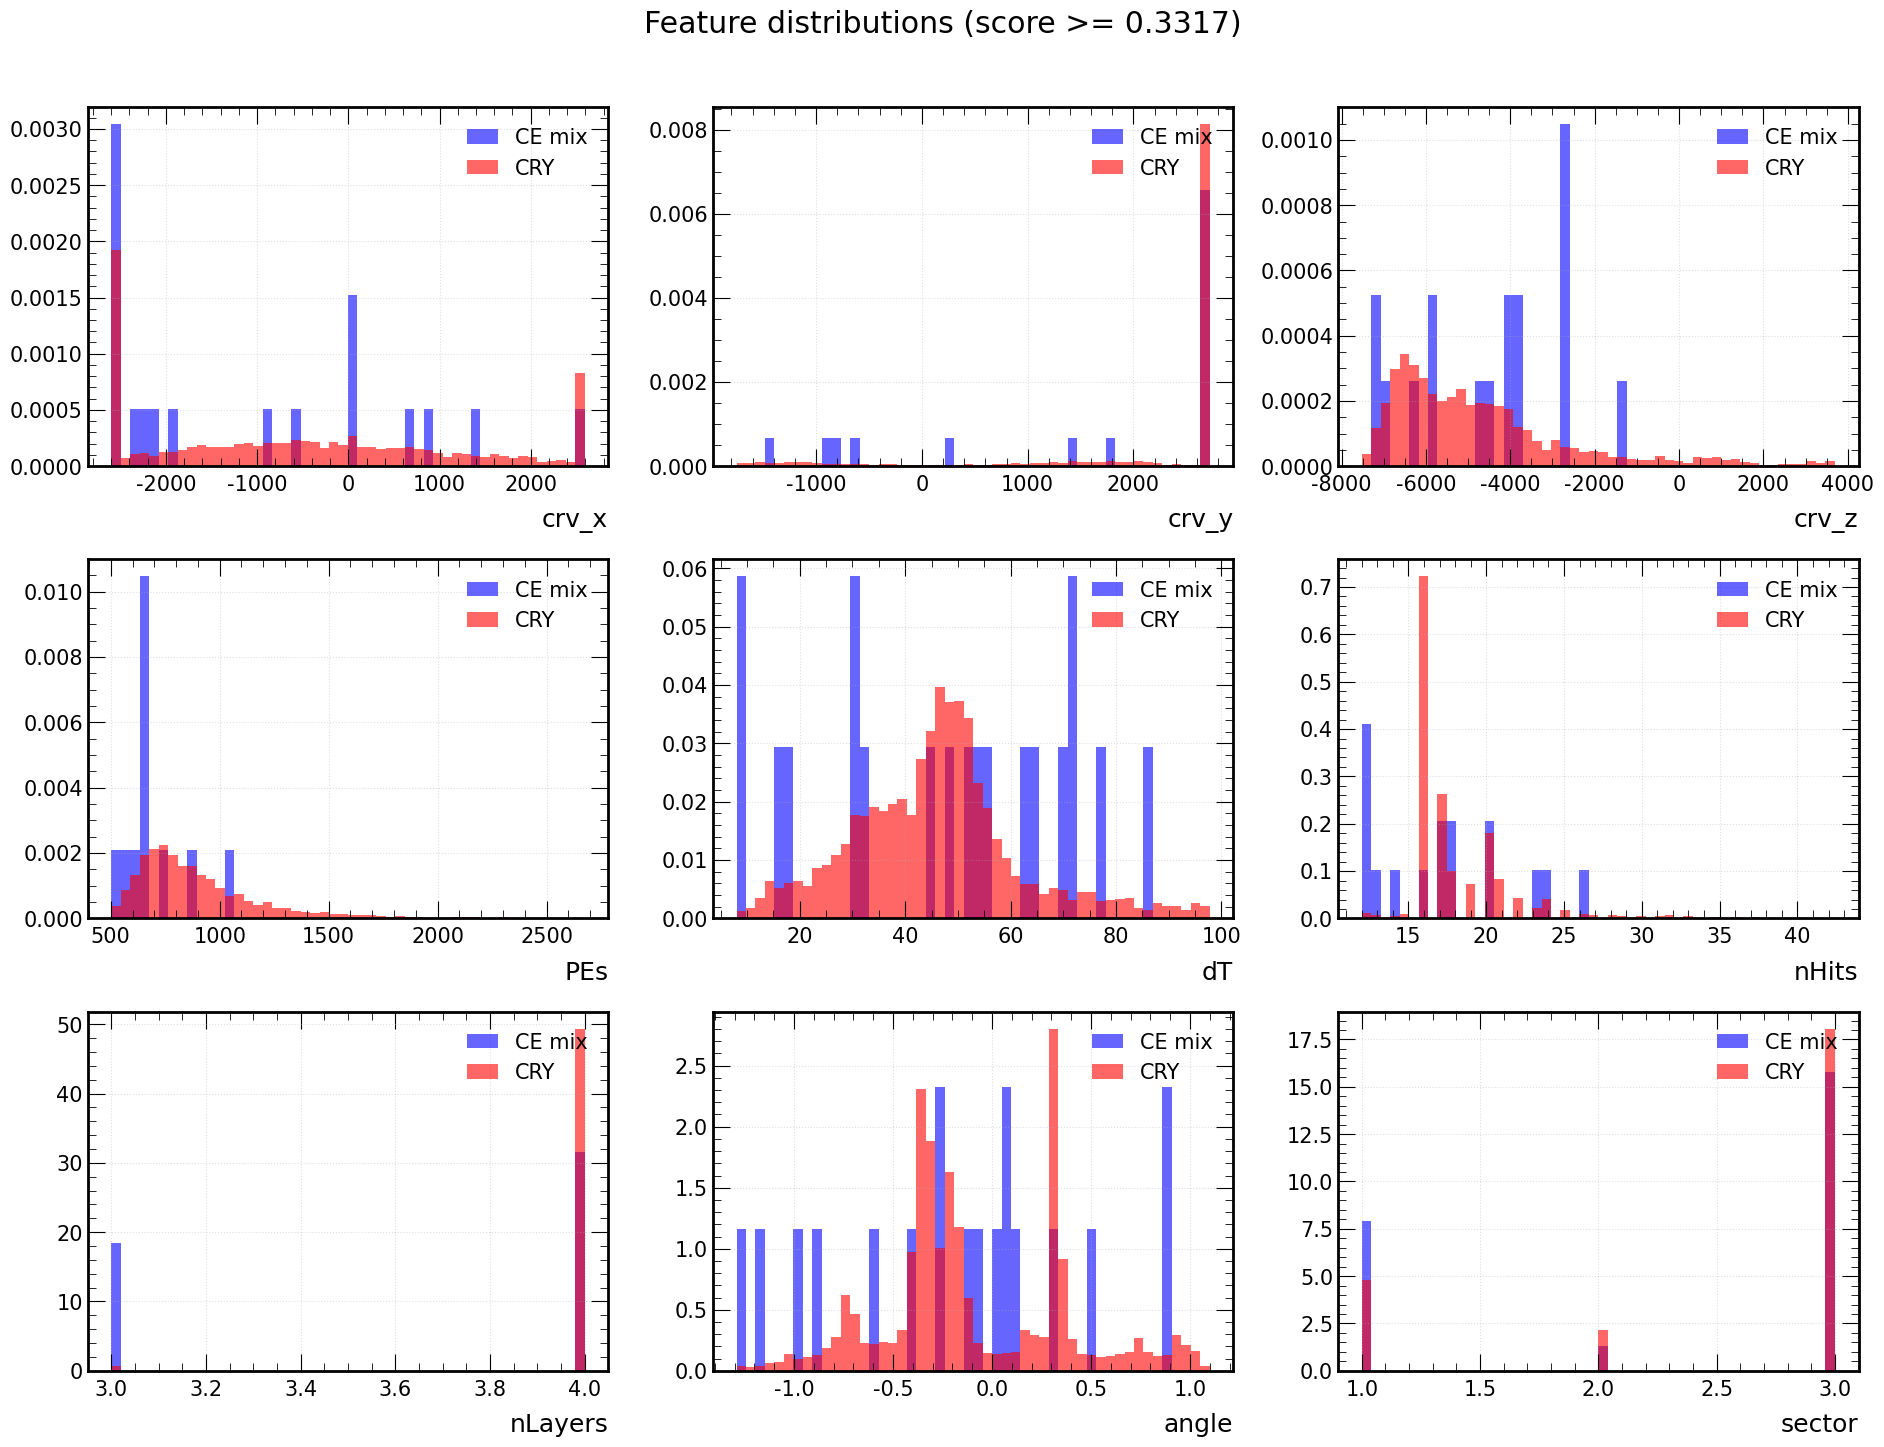

[AnaModel] [INFO] Selected events (score < 0.3317):
  CRY:    22
  CE mix: 84494

Low-score CRY events:
   event  subrun    score
303841.0 40396.0 0.000013
 96378.0 18895.0 0.000397
444004.0 64582.0 0.115619
491783.0 24363.0 0.171987
328545.0 54267.0 0.329397
107124.0 52416.0 0.039677
 95964.0 33846.0 0.020969
491991.0 73454.0 0.196071
416943.0  1978.0 0.003718
  9224.0 20155.0 0.021827
106851.0  3492.0 0.003526
283585.0  4846.0 0.000041
416133.0 33264.0 0.307932
169398.0 71280.0 0.014691
166209.0 35272.0 0.093276
287217.0 24158.0 0.029393
322935.0 59093.0 0.098095
180485.0 61342.0 0.051578
426274.0 76525.0 0.000004
283308.0 35908.0 0.000295
369509.0 63500.0 0.022269
145780.0 18881.0 0.281305

[AnaModel] [OK] Saved low-score CRY events to ../../output/images/ml/j/xgb_optimal/low_score_cry.csv
[AnaModel] [OK] Saved to ../../output/images/ml/j/xgb_optimal/h1_low_score_physics.png


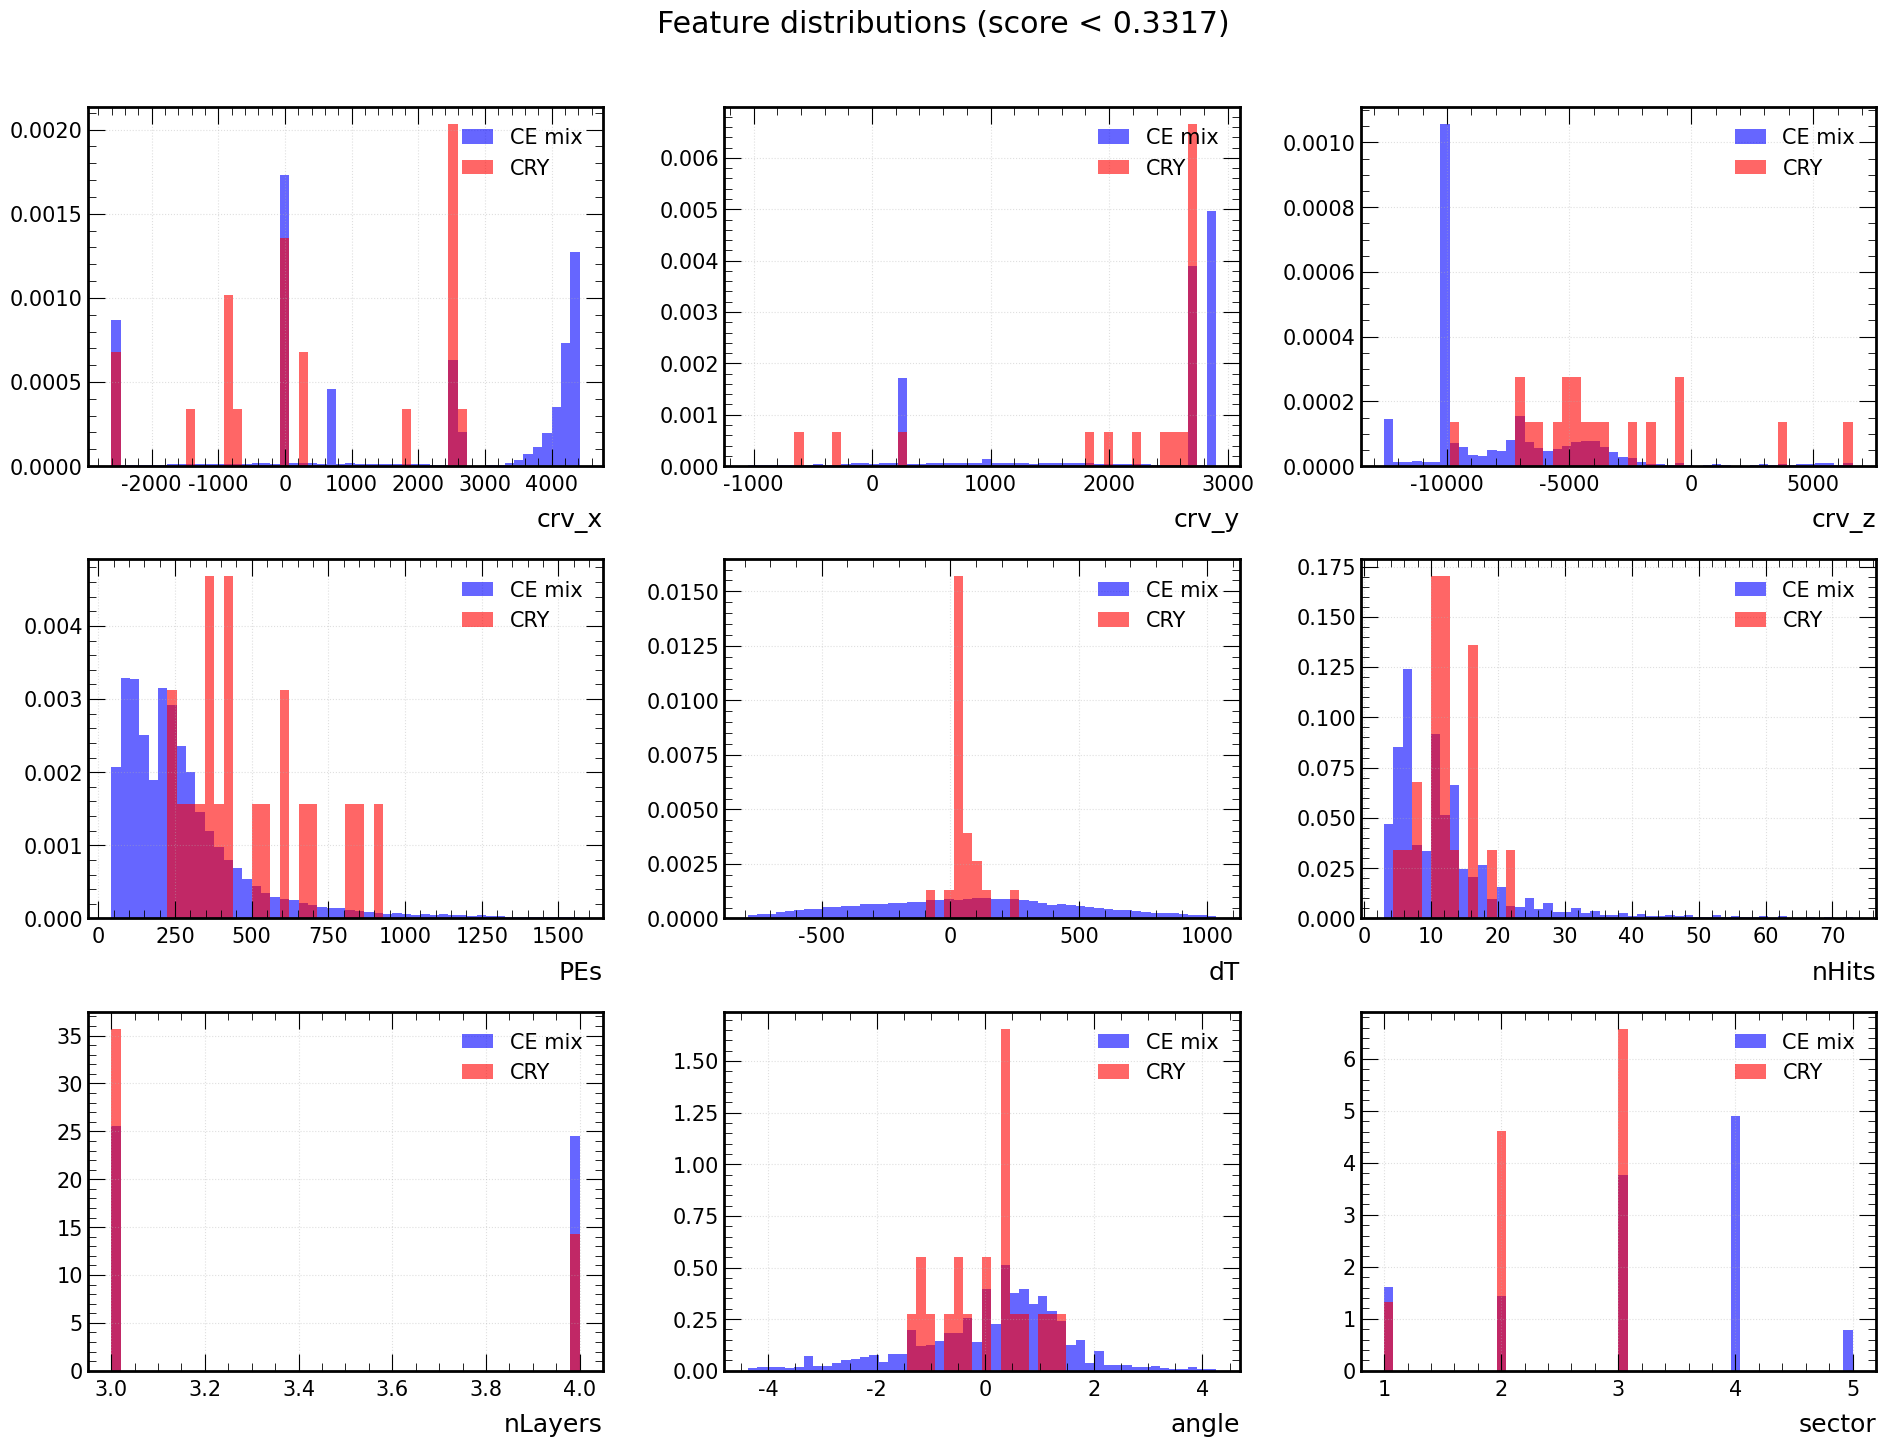

Test dataset:
[AnaModel] [OK] Saved comparison tables to ../../output/ml/j/results/xgb_optimal


,Category,ML model,dT cut,Difference
0,True Positives (CRY vetoed),3967,3967,0
1,True Negatives (CE mix passed),59448,52849,6599
2,False Positives (CE mix vetoed),19,6618,-6599
3,False Negatives (CRY passed),3,3,0


,Metric,ML model,"dT cut [0, 150] ns",Difference,Description
0,Veto efficiency,99.924%,99.924%,+0.000%,Fraction of cosmics vetoed
1,Deadtime,0.032%,11.129%,-11.097%,Fraction of CE mix vetoed
2,Veto purity,99.523%,37.478%,+62.046%,"Of vetoed events, fraction that are cosmics"
3,Overall accuracy,99.965%,89.563%,+10.402%,Overall correct classification rate
4,Figure of merit,99.893%,88.804%,+11.089%,eff_veto * (1 - deadtime)


Full dataset:
[AnaModel] [OK] Saved comparison tables to ../../output/ml/j/results/xgb_optimal


,Category,ML model,dT cut,Difference
0,True Positives (CRY vetoed),19566,19564,2
1,True Negatives (CE mix passed),297590,264758,32832
2,False Positives (CE mix vetoed),19,32851,-32832
3,False Negatives (CRY passed),8,10,-2


,Metric,ML model,"dT cut [0, 150] ns",Difference,Description
0,Veto efficiency,99.959%,99.949%,+0.010%,Fraction of cosmics vetoed
1,Deadtime,0.006%,11.038%,-11.032%,Fraction of CE mix vetoed
2,Veto purity,99.903%,37.325%,+62.578%,"Of vetoed events, fraction that are cosmics"
3,Overall accuracy,99.991%,89.640%,+10.352%,Overall correct classification rate
4,Figure of merit,99.953%,88.916%,+11.037%,eff_veto * (1 - deadtime)


In [5]:
# Now test/validate the model 
from analyse_model import AnaModel
ana = AnaModel(training_results)
ana.print_summary()
ana.plot_feature_importance()
ana.plot_roc(show=True)
threshold_results = ana.find_threshold(show=False)

ana.plot_score_distribution(threshold=threshold_results["threshold"])

ana.plot_physics_by_score(
    df_full=data["df_full"],
    threshold=threshold_results["threshold"],
    above=True
)

ana.plot_physics_by_score(
    df_full=data["df_full"],
    threshold=threshold_results["threshold"],
    above=False
)

print("Test dataset:")
money_test = ana.money_table(
    X=data["X_test"],
    y=data["y_test"],
    metadata=data["metadata_test"],
    threshold=threshold_results["threshold"]
)
display(money_test["confusion"])
display(money_test["metrics"])

print("Full dataset:")
money_full = ana.money_table(
    X=data["df_full"][ana.feature_names],
    y=data["df_full"]["label"],
    metadata=data["df_full"][["subrun", "event"]],
    threshold=threshold_results["threshold"]
)
display(money_full["confusion"])
display(money_full["metrics"])